In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import yaml
import torch

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    homogeneity_score,
)
from sklearn.neighbors import NearestNeighbors

import umap
import igraph as ig
import leidenalg as la

from clearit.config import MODELS_DIR, DATASETS_DIR
from clearit.inference.utils import get_embeddings


In [4]:
# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

encoder_id = "E0030"          # pretrained encoder

# TRAIN comes from TME-A_ML6 (from encoder cfg)
# TEST comes from inForm_MC7 (explicitly)
test_annotation_name = "inForm_MC7"
test_index_rel_path  = "indices/test/test_full01.npz"

# subsampling
n_train_subsample = 200_000
n_test_subsample  = 50_000

# PCA & clustering
pca_components        = 64
kmeans_clusters       = 10
knn_neighbors_graph   = 30   # kNN for Leiden graph
knn_neighbors_assign  = 10   # neighbors for assigning Leiden to test


In [5]:
# ------------------------------------------------------------
# 1. Load encoder config (tells us TME annotation + train split)
# ------------------------------------------------------------

enc_dir = MODELS_DIR / "encoders" / encoder_id
enc_cfg_path = enc_dir / "conf_enc.yaml"
enc_cfg = yaml.safe_load(enc_cfg_path.read_text())

train_dataset_name     = enc_cfg["dataset_name"]      # e.g. "TNBC1-MxIF8"
train_annotation_name  = enc_cfg["annotation_name"]   # e.g. "TME-A_ML6"
train_index_rel_path   = enc_cfg["data_index_list"]   # e.g. "indices/train/train_full01.npz"

print("Encoder config loaded from:", enc_cfg_path)
print("  train dataset     :", train_dataset_name)
print("  train annotation  :", train_annotation_name)
print("  train index list  :", train_index_rel_path)


Encoder config loaded from: /workspace/files/CLEAR-IT/models/encoders/E0030/conf_enc.yaml
  train dataset     : TNBC1-MxIF8
  train annotation  : TME-A_ML6
  train index list  : indices/pretrain/N409600.npz


In [6]:
# ------------------------------------------------------------
# 2. Build TRAIN dataframe from TME-A_ML6 (pretraining annotation)
# ------------------------------------------------------------

train_labels_path = DATASETS_DIR / train_dataset_name / train_annotation_name / "labels.csv"
df_train_tme = pd.read_csv(train_labels_path)

train_npz_path = DATASETS_DIR / train_dataset_name / train_annotation_name / train_index_rel_path
arr_train = np.load(train_npz_path)
train_files = arr_train.files

if len(train_files) == 1:
    train_indices = arr_train[train_files[0]]
else:
    # first array = indices, second = channels (for SimCLR); ignore channel here
    train_indices = arr_train[train_files[0]]

df_train = df_train_tme.iloc[train_indices].reset_index(drop=True)

# ensure one row per cell
key_cols = ["fname", "cell_x", "cell_y"]
df_train = df_train.drop_duplicates(subset=key_cols).reset_index(drop=True)

print("TME-A_ML6 train df shape:", df_train.shape)


TME-A_ML6 train df shape: (369550, 6)


In [7]:
# ------------------------------------------------------------
# 3. Build TEST dataframe from inForm_MC7
# ------------------------------------------------------------

dataset_name = train_dataset_name         # same images
test_labels_path = DATASETS_DIR / dataset_name / test_annotation_name / "labels.csv"
df_all_mc7 = pd.read_csv(test_labels_path)

test_npz_path = DATASETS_DIR / dataset_name / test_annotation_name / test_index_rel_path
arr_test = np.load(test_npz_path)
test_files = arr_test.files
test_indices = arr_test[test_files[0]]

df_test = df_all_mc7.iloc[test_indices].reset_index(drop=True)
df_test = df_test.drop_duplicates(subset=key_cols).reset_index(drop=True)

print("inForm_MC7 test df shape:", df_test.shape)


inForm_MC7 test df shape: (572648, 6)


In [8]:
# ------------------------------------------------------------
# 4. Subsample train & test
# ------------------------------------------------------------

if len(df_train) > n_train_subsample:
    df_train = df_train.sample(n_train_subsample, random_state=0).reset_index(drop=True)
if len(df_test) > n_test_subsample:
    df_test = df_test.sample(n_test_subsample, random_state=0).reset_index(drop=True)

print("Subsampled TME train:", df_train.shape)
print("Subsampled MC7 test :", df_test.shape)


Subsampled TME train: (200000, 6)
Subsampled MC7 test : (50000, 6)


In [9]:
# make sure crops match encoder training
if "img_size" in enc_cfg:
    df_train.attrs["img_size"] = int(enc_cfg["img_size"])
    df_test.attrs["img_size"]  = int(enc_cfg["img_size"])


In [12]:
# ------------------------------------------------------------
# 5. Extract encoder embeddings (multiplex features)
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X_train = get_embeddings(
    df_train,
    dataset_name=train_dataset_name,
    annotation_name=train_annotation_name,   # TME-A_ML6
    encoder_id=encoder_id,
    batch_size=128,
    num_workers=20,
    proj_layers=0,
    device=device,
).cpu().numpy()

X_test = get_embeddings(
    df_test,
    dataset_name=dataset_name,
    annotation_name=test_annotation_name,    # inForm_MC7
    encoder_id=encoder_id,
    batch_size=128,
    num_workers=20,
    proj_layers=0,
    device=device,
).cpu().numpy()

print("Train features shape:", X_train.shape)   # [N_train, 4096]
print("Test  features shape:", X_test.shape)


Using device: cuda
Loaded & padded 761 images in 139.0s (5.5 f/s)
Extracted 200000 crops in 102.8s (1945.4 crops/s)
Loaded & padded 248 images in 71.2s (3.5 f/s)
Extracted 50000 crops in 24.4s (2045.6 crops/s)
Train features shape: (200000, 4096)
Test  features shape: (50000, 4096)


In [13]:
if "label" not in df_test.columns:
    raise KeyError("Expected an integer 'label' column in inForm_MC7 labels.")
y_test = df_test["label"].astype(int).to_numpy()
print("Test label counts:", np.bincount(y_test))


Test label counts: [21407 25363  1146  1055   414    95   520]


In [14]:
# ------------------------------------------------------------
# 6. PCA on train features, apply to test
# ------------------------------------------------------------

pca_dim = min(pca_components, X_train.shape[1])
pca = PCA(n_components=pca_dim, random_state=0)

X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print("PCA dim:", pca_dim)
print("Explained variance ratio (sum):", float(pca.explained_variance_ratio_.sum()))
print("X_train_pca:", X_train_pca.shape)
print("X_test_pca :", X_test_pca.shape)


PCA dim: 64
Explained variance ratio (sum): 0.9183615741476714
X_train_pca: (200000, 64)
X_test_pca : (50000, 64)


In [15]:
# ------------------------------------------------------------
# 7A. k-means on PCA(train), assign to test
# ------------------------------------------------------------

kmeans = KMeans(n_clusters=kmeans_clusters, random_state=0, n_init=10)
cluster_train_km = kmeans.fit_predict(X_train_pca)
cluster_test_km  = kmeans.predict(X_test_pca)

print("k-means clusters (train):", np.bincount(cluster_train_km))
print("k-means clusters (test) :", np.bincount(cluster_test_km))


k-means clusters (train): [16166 12881  1925 18368 38170 31239 19652  7345 33439 20815]
k-means clusters (test) : [ 4479  4057   769  1823 11181  9034  7842  2812  6018  1985]


In [16]:
ami_km  = adjusted_mutual_info_score(y_test, cluster_test_km)
ari_km  = adjusted_rand_score(y_test, cluster_test_km)
homo_km = homogeneity_score(y_test, cluster_test_km)

print(f"[k-means vs MC7] AMI={ami_km:.3f}, ARI={ari_km:.3f}, Homogeneity={homo_km:.3f}")


[k-means vs MC7] AMI=0.000, ARI=0.000, Homogeneity=0.001


In [17]:
# ------------------------------------------------------------
# 7B. Graph + Leiden on PCA(train), assign to test
# ------------------------------------------------------------

# kNN graph on train
nn = NearestNeighbors(n_neighbors=knn_neighbors_graph + 1, metric="euclidean")
nn.fit(X_train_pca)
distances, indices = nn.kneighbors(X_train_pca)

sources = np.repeat(np.arange(X_train_pca.shape[0]), knn_neighbors_graph)
targets = indices[:, 1:].reshape(-1)

g = ig.Graph(n=X_train_pca.shape[0], edges=list(zip(sources, targets)), directed=False)
g.simplify(combine_edges="first")

partition = la.find_partition(g, la.RBConfigurationVertexPartition, resolution_parameter=1.0)
cluster_train_leiden = np.array(partition.membership)

print("Leiden clusters (train):", np.bincount(cluster_train_leiden))
print("Number of Leiden clusters:", cluster_train_leiden.max() + 1)


Leiden clusters (train): [21215 19743 19070 17359 16408 14206 13195 12104 12091 10550  9433  9365
  6810  4859  3970  3378  2924  2072   991   257]
Number of Leiden clusters: 20


In [18]:
# assign test cells by nearest neighbors in train PCA space
nn_assign = NearestNeighbors(n_neighbors=knn_neighbors_assign, metric="euclidean")
nn_assign.fit(X_train_pca)
dist_test, idx_test = nn_assign.kneighbors(X_test_pca)

cluster_test_leiden = []
for neigh in idx_test:
    labs = cluster_train_leiden[neigh]
    values, counts = np.unique(labs, return_counts=True)
    cluster_test_leiden.append(values[counts.argmax()])
cluster_test_leiden = np.array(cluster_test_leiden, dtype=int)

print("Leiden clusters (test):", np.bincount(cluster_test_leiden))


Leiden clusters (test): [5301 4390 3952 9146 6001 4009 2136  968 3710 2591  639 2559  515 2921
  119   52  952   33    6]


In [19]:
ami_lei  = adjusted_mutual_info_score(y_test, cluster_test_leiden)
ari_lei  = adjusted_rand_score(y_test, cluster_test_leiden)
homo_lei = homogeneity_score(y_test, cluster_test_leiden)

print(f"[Leiden vs MC7] AMI={ami_lei:.3f}, ARI={ari_lei:.3f}, Homogeneity={homo_lei:.3f}")


[Leiden vs MC7] AMI=0.000, ARI=0.000, Homogeneity=0.001


In [20]:
# ------------------------------------------------------------
# 8. UMAP on PCA(test) for visualization
# ------------------------------------------------------------

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=0,
)

emb_test = umap_model.fit_transform(X_test_pca)
print("UMAP(test) shape:", emb_test.shape)


OMP: Info #273: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP(test) shape: (50000, 2)


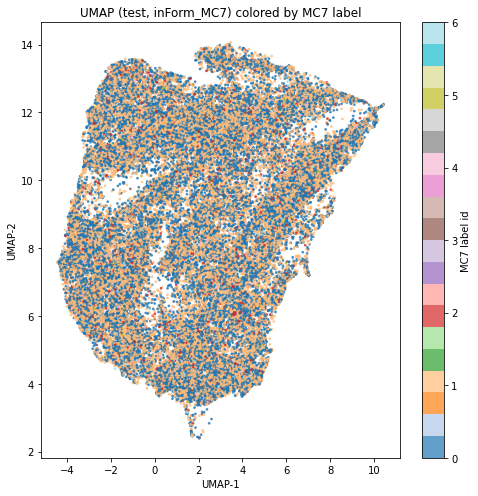

In [21]:
plt.figure(figsize=(7, 7))
scatter = plt.scatter(
    emb_test[:, 0],
    emb_test[:, 1],
    c=y_test,
    cmap="tab20",
    s=3,
    alpha=0.7,
)

plt.title("UMAP (test, inForm_MC7) colored by MC7 label")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label="MC7 label id")
plt.tight_layout()
plt.show()


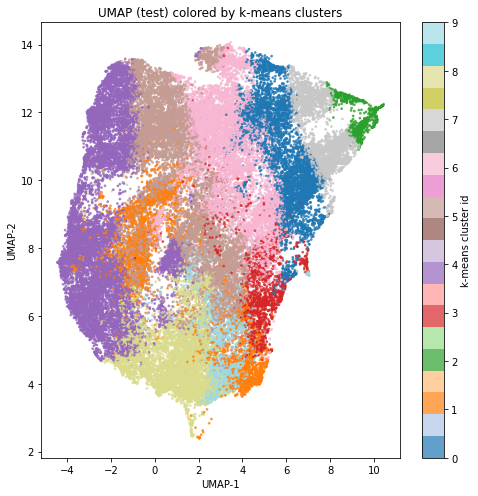

In [22]:
plt.figure(figsize=(7, 7))
plt.scatter(
    emb_test[:, 0],
    emb_test[:, 1],
    c=cluster_test_km,
    cmap="tab20",
    s=3,
    alpha=0.7,
)
plt.title("UMAP (test) colored by k-means clusters")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label="k-means cluster id")
plt.tight_layout()
plt.show()


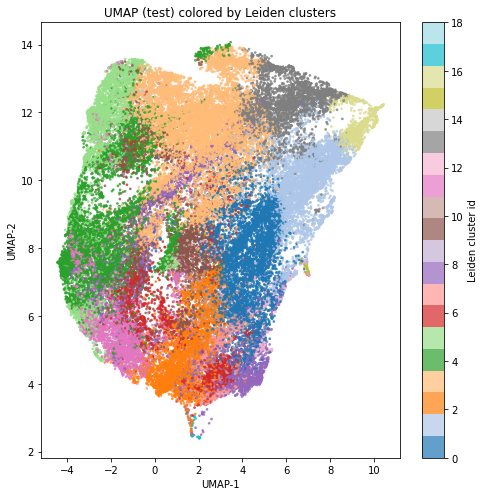

In [23]:
plt.figure(figsize=(7, 7))
plt.scatter(
    emb_test[:, 0],
    emb_test[:, 1],
    c=cluster_test_leiden,
    cmap="tab20",
    s=3,
    alpha=0.7,
)
plt.title("UMAP (test) colored by Leiden clusters")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label="Leiden cluster id")
plt.tight_layout()
plt.show()


In [24]:
# Contingency table: cluster vs label (for k-means)
import pandas as pd
ct_km = pd.crosstab(cluster_test_km, y_test, normalize="index")
display(ct_km)

# same for Leiden
ct_lei = pd.crosstab(cluster_test_leiden, y_test, normalize="index")
display(ct_lei)


col_0,0,1,2,3,4,5,6
row_0,,,,,,,
0,0.433802,0.498326,0.022773,0.022326,0.008931,0.003126,0.010717
1,0.434311,0.504067,0.023170,0.021198,0.008134,0.000986,0.008134
2,0.436931,0.496749,0.033810,0.011704,0.005202,0.001300,0.014304
3,0.415250,0.522216,0.019199,0.018651,0.011519,0.003840,0.009325
4,0.428853,0.509704,0.022091,0.020034,0.008854,0.001610,0.008854
5,0.426389,0.506531,0.022139,0.024685,0.006642,0.002435,0.011180
6,0.432033,0.505611,0.022953,0.020275,0.007014,0.001403,0.010712
7,0.424609,0.506046,0.020982,0.023115,0.009957,0.002134,0.013158
8,0.417747,0.516617,0.025424,0.019940,0.008641,0.001496,0.010136


col_0,0,1,2,3,4,5,6
row_0,,,,,,,
0,0.430485,0.506697,0.020939,0.020939,0.007923,0.002075,0.010941
1,0.424374,0.501367,0.025968,0.024146,0.008200,0.002961,0.012984
2,0.420040,0.519990,0.020496,0.019484,0.008350,0.000759,0.010881
3,0.433742,0.503280,0.024601,0.020665,0.006342,0.002296,0.009075
4,0.433594,0.500417,0.022996,0.021996,0.009498,0.001333,0.010165
5,0.422050,0.520329,0.020205,0.017211,0.008481,0.002245,0.009479
6,0.425562,0.506086,0.022940,0.026217,0.007491,0.002341,0.009363
7,0.448347,0.485537,0.021694,0.021694,0.010331,0.001033,0.011364
8,0.411860,0.520755,0.024259,0.020216,0.009164,0.000809,0.012938


In [25]:
from scipy.stats import entropy

def cluster_label_entropy(clusters, labels):
    df = pd.DataFrame({"cluster": clusters, "label": labels})
    entropies = []
    for c, group in df.groupby("cluster"):
        p = group["label"].value_counts(normalize=True).values
        entropies.append((c, entropy(p, base=2)))
    return pd.DataFrame(entropies, columns=["cluster", "entropy_bits"])

print("k-means cluster entropies:")
display(cluster_label_entropy(cluster_test_km, y_test))

print("Leiden cluster entropies:")
display(cluster_label_entropy(cluster_test_leiden, y_test))


k-means cluster entropies:


,cluster,entropy_bits
0,0,1.427077
1,1,1.387223
2,2,1.403236
3,3,1.400501
4,4,1.389619
5,5,1.416595
6,6,1.393171
7,7,1.431955
8,8,1.406041
9,9,1.436541


Leiden cluster entropies:


,cluster,entropy_bits
0,0,1.399078
1,1,1.453736
2,2,1.378352
3,3,1.396373
4,4,1.412668
5,5,1.372083
6,6,1.420884
7,7,1.416563
8,8,1.412722
9,9,1.419641


In [29]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_km  = silhouette_score(X_test_pca, cluster_test_km)
db_km   = davies_bouldin_score(X_test_pca, cluster_test_km)

sil_lei = silhouette_score(X_test_pca, cluster_test_leiden)
db_lei  = davies_bouldin_score(X_test_pca, cluster_test_leiden)

print(f"k-means: silhouette={sil_km:.3f}, Davies-Bouldin={db_km:.3f}")
print(f"Leiden : silhouette={sil_lei:.3f}, Davies-Bouldin={db_lei:.3f}")


k-means: silhouette=0.097, Davies-Bouldin=2.202
Leiden : silhouette=0.029, Davies-Bouldin=2.558
